# CFM Pipeline Test
Load CFM model, pass an image, get concept vector. Verify pipeline works before smoothing experiments.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from pathlib import Path

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.9.1+cu128
CUDA available: True
GPU: NVIDIA A16


In [2]:
# Load CFM Model (CLIP-DINOiser + SAE)
from cfm.arg_parser import get_default_parser
from cfm.utils import common_init, get_img_model
from cfm.cfm import CFM
from dictionary_learning.utils import load_dictionary

# SAE config name (from Kai's directory)
CONFIG_NAME = 'k_12_ef_16_lr_0.0001_mf_[0.008,0.03,0.06,0.12,0.24,0.542]'

# Build args from config.py defaults
parser = get_default_parser()
args = parser.parse_args([])
args.device = 'cuda' if torch.cuda.is_available() else 'cpu'
common_init(args)
args.config_name = CONFIG_NAME

print("Device:", args.device)
print("Image encoder:", args.img_enc_name)
print("SAE checkpoint dir:", args.save_dir_sae_ckpts['img'])

/BS/dniazi_thesis/work/miniforge3_new/envs/cfm-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Image encoder: dinoclip_ViT-B/16
SAE checkpoint dir: /scratch/inf0/user/kwittenm/SAE/cc12m/dinoclip_ViT-B16/matryoshka/sae_checkpoints


In [3]:
# Load Feature Extractor (CLIP-DINOiser)
feature_extractor, preprocess = get_img_model(args)
feature_extractor.eval()
print("CLIP-DINOiser loaded")

{'_base_': 'default.yml', 'seed': 0, 'model_name': 'CLIP_DINOiser', 'model': {'_target_': 'cfm.clip_dinoiser_backbone.clip_dinoiser.CLIP_DINOiser', 'clip_backbone': 'maskclip', 'vit_arch': 'vit_base', 'vit_patch_size': 16, 'enc_type_feats': 'v', 'gamma': 0.2, 'in_dim': 256, 'delta': 0.99, 'feats_idx': -3}, 'check_path': 'checkpoints/last.pt', 'work_dir': 'output', 'train': {'batch_size': 16, 'corr_lr': 5e-05, 'found_lr': 0.01, 'num_workers': 4, 'epochs': 100, 'milestones': [5000], 'step_lr_gamma': 0.1, 'data': '/home/data/imagenet', 'loss': 'CE', 'ds_size': 1000, 'im_size': 448}, 'output': 'output', 'evaluate': {'eval_only': True, 'task': ['voc', 'context', 'coco_object', 'context59', 'voc20', 'coco_stuff', 'cityscapes', 'ade20k'], 'voc': 'segmentation/configs/_base_/datasets/pascal_voc12.py', 'voc20': 'segmentation/configs/_base_/datasets/pascal_voc12_20.py', 'context': 'segmentation/configs/_base_/datasets/pascal_context.py', 'context59': 'segmentation/configs/_base_/datasets/pascal_

In [4]:
# Load SAE 
sae_base = Path(args.save_dir_sae_ckpts['img']) / args.config_name / 'trainer_0'
print("Looking for SAE at:", sae_base)
print("Exists:", sae_base.exists())

if sae_base.exists():
    autoencoder, ae_config = load_dictionary(str(sae_base), args.device)
    print("SAE loaded")
    print("SAE config:", ae_config)
else:
    # List what's available
    sae_parent = Path(args.save_dir_sae_ckpts['img'])
    print("Available SAE configs:")
    if sae_parent.exists():
        for d in sae_parent.iterdir():
            print(f"  - {d.name}")
    else:
        print(f"  SAE parent dir doesn't exist: {sae_parent}")
        print("  Check config.py paths!")

Looking for SAE at: /scratch/inf0/user/kwittenm/SAE/cc12m/dinoclip_ViT-B16/matryoshka/sae_checkpoints/k_12_ef_16_lr_0.0001_mf_[0.008,0.03,0.06,0.12,0.24,0.542]/trainer_0
Exists: True
SAE loaded
SAE config: {'trainer': {'trainer_class': 'MatryoshkaBatchTopKTrainer', 'dict_class': 'MatryoshkaBatchTopKSAE', 'lr': 0.0001, 'steps': 118935, 'auxk_alpha': 0.03125, 'warmup_steps': 500, 'decay_start': None, 'threshold_beta': 0.999, 'threshold_start_step': 1000, 'top_k_aux': 256, 'seed': 42, 'activation_dim': 512, 'dict_size': 8192, 'group_fractions': [0.008, 0.03, 0.06, 0.12, 0.24, 0.542], 'group_weights': [0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666], 'group_sizes': [65, 245, 491, 983, 1966, 4442], 'k': 12, 'device': 'cuda', 'layer': 3, 'lm_name': 'dinoclip_ViT-B/16', 'wandb_name': 'k_12_ef_16_lr_0.0001_mf_[0.008,0.03,0.06,0.12,0.24,0.542]dft_10000000', 'submodule_name': 'patch_tokens_of_last_layer'}}


In [5]:
# Create CFM model
cfm_model = CFM(
    feature_extractor=feature_extractor,
    autoencoder=autoencoder,
    apply_found=False,
    device=args.device,
)
cfm_model.eval()
print("CFM model ready")

CFM model ready


In [6]:
# Load concept names from my directory
concept_name_save_path = '/BS/dniazi_thesis/work/cfm_data/concept_names.txt'
print("Looking for concept names at:", concept_name_save_path)

if os.path.exists(concept_name_save_path):
    with open(concept_name_save_path, "r") as f:
        concept_names = [line.strip() for line in f.readlines()]
    print(f"Loaded {len(concept_names)} concept names")
    print("First 20:", concept_names[:20])
else:
    concept_names = None
    print("Concept names file not found, using indices instead.")

Looking for concept names at: /BS/dniazi_thesis/work/cfm_data/concept_names.txt
Loaded 8192 concept names
First 20: ['flavorful', 'dog breed', 'vortex vein', 'baking dish', 'squarepants', 'bed covering', 'mens t', 'range of mountains', 'palaces', 'wallpapersafari', 'attractive woman', 'small resolution', 'productafbeelding', 'dinner dress', 'shirtsleeve', 'kitchen range', 'outdoor christmas', 'grass field', 'baked goods', 'industrial style']


## Test image through pipeline

Image size: (500, 375)
Tensor shape: torch.Size([1, 3, 224, 224])
Image size: (500, 375)


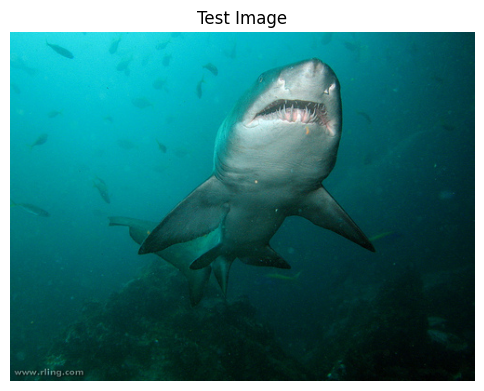

In [7]:
# Load a test image
import urllib.request
test_img_path = "idx199_input.JPEG"

# Option B: Use an image from a dataset
# Load and preprocess
image = Image.open(test_img_path).convert("RGB")
image_tensor = preprocess(image).unsqueeze(0).to(args.device)

print(f"Image size: {image.size}")
print(f"Tensor shape: {image_tensor.shape}")
print(f"Image size: {image.size}")
# Display
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title("Test Image")
plt.axis("off")
plt.show()

In [8]:
# Get concept vector
with torch.no_grad():
    concept_vector = cfm_model.get_aggregated_concept_activations(image_tensor)  # [1, 8192]
    concept_maps = cfm_model.get_concept_activation_map(image_tensor)  # [1, 8192, 28, 28]

print("=" * 60)
print("CONCEPT VECTOR (image-level, max-pooled)")
print("=" * 60)
print(f"Shape: {concept_vector.shape}")
print(f"Non-zero concepts: {(concept_vector[0] > 0).sum().item()} / {concept_vector.shape[1]}")
print(f"Min (non-zero): {concept_vector[concept_vector > 0].min().item():.4f}")
print(f"Max: {concept_vector.max().item():.4f}")
print(f"Mean (non-zero): {concept_vector[concept_vector > 0].mean().item():.4f}")

print(f"\n{'=' * 60}")
print("CONCEPT MAPS (spatial)")
print("=" * 60)
print(f"Shape: {concept_maps.shape}")

# Top active concepts
top_k = 20
top_values, top_indices = concept_vector[0].topk(top_k)
print(f"\nTop {top_k} active concepts:")
for i, (idx, val) in enumerate(zip(top_indices, top_values)):
    name = concept_names[idx.item()] if concept_names else f"concept_{idx.item()}"
    print(f"  {i+1:2d}. [{idx.item():4d}] {name:30s} = {val.item():.4f}")

CONCEPT VECTOR (image-level, max-pooled)
Shape: torch.Size([1, 8192])
Non-zero concepts: 48 / 8192
Min (non-zero): 0.4522
Max: 3.8544
Mean (non-zero): 1.0749

CONCEPT MAPS (spatial)
Shape: torch.Size([1, 8192, 14, 14])

Top 20 active concepts:
   1. [ 211] underwater                     = 3.8544
   2. [1273] great white shark              = 3.3569
   3. [ 339] minke whale                    = 3.2467
   4. [ 740] reefs                          = 2.7136
   5. [  53] body of water                  = 2.6874
   6. [ 259] food fish                      = 2.0499
   7. [ 831] religious holiday              = 1.8295
   8. [2023] underwater                     = 1.5322
   9. [  56] baby animal                    = 1.4241
  10. [  59] ncaa                           = 1.3758
  11. [  58] tropical beach                 = 1.3508
  12. [  22] additional photo               = 1.2265
  13. [ 256] corals                         = 1.1814
  14. [ 202] grimace                        = 1.1239
  15. [  37] w

## Manifold Smoothing in Concept Space
Generate concept vectors for a dataset, build KNN index, then apply
PCA-based manifold smoothing on concept vectors (analogous to Jonas's pixel-space pipeline).

In [9]:
# Load probe dataset and linear classifier weights
from cfm import config as cfm_config
from cfm.utils import get_probe_dataset
from cfm.method_utils import MethodCFM

PROBE_DATASET = "imagenet"  # or "places365"
PROBE_SPLIT = "val"

args.probe_dataset = PROBE_DATASET
args.probe_split = PROBE_SPLIT
args.probe_dataset_root_dir = cfm_config.probe_dataset_root_dir_dict[PROBE_DATASET]

probe_val_dataset = get_probe_dataset(
    PROBE_DATASET, PROBE_SPLIT, args.probe_dataset_root_dir, preprocess_fn=preprocess)
print(f"Dataset: {PROBE_DATASET} ({PROBE_SPLIT}), {len(probe_val_dataset)} samples")

# Load linear probe: concept_vector @ classifier_weights.T -> class logits
if not hasattr(args, "autoencoder_input_dim_dict"):
    args.autoencoder_input_dim_dict = cfm_config.autoencoder_input_dim_dict

method_obj = MethodCFM(args, vocab_txt_path=None)

# Probe config: no sparsity, max pooling, no threshold
PROBE_CONFIG = "lr0.0001_bs512_epo50_clCE_spL1_spl0.0max_no_threshold"
probe_base = os.path.join(
    args.probe_cs_save_dir_root, args.sae_dataset,
    args.img_enc_name_for_saving, args.hook_points[0],
    args.config_name, PROBE_DATASET, PROBE_CONFIG, "on_concepts_ckpts")
# Find the checkpoint file
ckpt_file = [f for f in os.listdir(probe_base) if f.endswith(".pt")][0]
ckpt_path = os.path.join(probe_base, ckpt_file)
print(f"Loading probe from: {ckpt_path}")

classifier_weights = method_obj.get_classifier_weights(
    probe_dataset=PROBE_DATASET, checkpoint_save_path=ckpt_path).to(args.device)
print(f"Classifier weights: {classifier_weights.shape}")  # [num_classes, 8192]

Dataset: imagenet (val), 50000 samples
SAE config_used: k_12_ef_16_lr_0.0001_mf_[0.008,0.03,0.06,0.12,0.24,0.542]
loading autoencoder from /scratch/inf0/user/kwittenm/SAE/cc12m/dinoclip_ViT-B16/matryoshka/sae_checkpoints/k_12_ef_16_lr_0.0001_mf_[0.008,0.03,0.06,0.12,0.24,0.542]/trainer_0
Loading probe from: /scratch/inf0/user/kwittenm/probe/cc12m/dinoclip_ViT-B16/out/k_12_ef_16_lr_0.0001_mf_[0.008,0.03,0.06,0.12,0.24,0.542]/imagenet/lr0.0001_bs512_epo50_clCE_spL1_spl0.0max_no_threshold/on_concepts_ckpts/on_concepts_final_lr0.0001_bs512_epo50_clCE_spL1_spl0.0_max_no_threshold.pt
Classifier weights: torch.Size([1000, 8192])


In [10]:
# Generate concept vectors for all images and save
# Each vector is [8192], sparse with ~12 non-zero entries
from torch.utils.data import DataLoader

SAVE_DIR = os.path.join("..", "smoothing_data")
os.makedirs(SAVE_DIR, exist_ok=True)

concept_vectors_path = os.path.join(
    SAVE_DIR, f"concept_vectors_{PROBE_DATASET}_{PROBE_SPLIT}.pt"
)
labels_path = os.path.join(
    SAVE_DIR, f"labels_{PROBE_DATASET}_{PROBE_SPLIT}.pt"
)

if os.path.exists(concept_vectors_path) and os.path.exists(labels_path):
    print("Loading existing concept vectors and labels...")
    all_concept_vectors = torch.load(concept_vectors_path, map_location="cpu")
    all_labels = torch.load(labels_path, map_location="cpu")
else:
    print("No saved concept vectors found. Building them now...")

    BATCH_SIZE = 64
    NUM_WORKERS = 4

    loader = DataLoader(
        probe_val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(args.device == "cuda"),
    )

    all_concept_vectors = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, (imgs, labels) in enumerate(loader):
            imgs = imgs.to(args.device)
            cvs = cfm_model.get_aggregated_concept_activations(imgs)  # [B, 8192]
            all_concept_vectors.append(cvs.cpu())
            all_labels.append(labels.cpu())

            if (batch_idx + 1) % 50 == 0:
                print(f"  Batch {batch_idx + 1}/{len(loader)}")

    all_concept_vectors = torch.cat(all_concept_vectors, dim=0)  # [N, 8192]
    all_labels = torch.cat(all_labels, dim=0)  # [N]

    torch.save(all_concept_vectors, concept_vectors_path)
    torch.save(all_labels, labels_path)
    print(f"Saved concept vectors to: {concept_vectors_path}")
    print(f"Saved labels to: {labels_path}")

print(f"Concept vectors shape: {all_concept_vectors.shape}")
print(f"Labels shape: {all_labels.shape}")
print(f"Non-zero per vector (mean): {(all_concept_vectors > 0).sum(1).float().mean():.1f}")

Loading existing concept vectors and labels...
Concept vectors shape: torch.Size([50000, 8192])
Labels shape: torch.Size([50000])
Non-zero per vector (mean): 88.4


In [11]:
# Build KNN index on concept vectors using Annoy
import annoy
import json

CONCEPT_DIM = all_concept_vectors.shape[1]  # 8192
N = all_concept_vectors.shape[0]

index_path = os.path.join(SAVE_DIR, f"knn_concepts_{PROBE_DATASET}_{PROBE_SPLIT}.ann")
N_TREES = 50

knn_index = annoy.AnnoyIndex(CONCEPT_DIM, "euclidean")

if os.path.exists(index_path):
    print(f"Loading existing Annoy index from: {index_path}")
    knn_index.load(index_path)
else:
    print("No saved Annoy index found. Building it now...")
    for i in range(N):
        knn_index.add_item(i, all_concept_vectors[i].numpy())

    knn_index.build(N_TREES)
    knn_index.save(index_path)
    print(f"Built Annoy index: {N} vectors, dim={CONCEPT_DIM}, trees={N_TREES}")
    print(f"Saved to {index_path}")

Loading existing Annoy index from: ../smoothing_data/knn_concepts_imagenet_val.ann


In [12]:
from cfm.data_utils import probe_classnames


# Parameters
K_NEIGHBORS = 500
SCALE_WEIGHT = 0.7
N_SMOOTH_SAMPLES = 100
TARGET_IDCS = [100, 51, 42, 200, 500]


def classify_concept_vector(cv, classifier_weights):
    """cv: [8192] -> predicted class index"""
    logits = cv @ classifier_weights.T
    return logits.argmax().item()

def get_class_name(probe_dataset, class_idx):
    names = probe_classnames.probe_classes_dict[probe_dataset]
    if probe_dataset == "places365":
        return " ".join(names[class_idx].split("/")[2:]).replace("_", " ")
    return names[class_idx]

def get_top_concept_names(cv, concept_names, top_k=10):
    """Return list of (name, value) for top-k active concepts"""
    vals, idxs = torch.topk(torch.tensor(cv), top_k)
    return [(concept_names[i.item()], v.item()) for i, v in zip(idxs, vals)]


 Below cell give Kernel error - please check gpu and compute node

In [13]:
# # Manifold smoothing on concept vectors
# from sklearn.decomposition import PCA


# for target_idx in TARGET_IDCS:
#     # Original concept vector and classification
#     cv_orig = all_concept_vectors[target_idx].numpy()
#     label_true = all_labels[target_idx].item()
#     pred_orig = classify_concept_vector(
#         torch.tensor(cv_orig, device=args.device), classifier_weights)

#     # Find K nearest neighbors in concept space
#     nn_idcs = knn_index.get_nns_by_item(target_idx, K_NEIGHBORS)
#     X_neighbors = np.stack([knn_index.get_item_vector(i) for i in nn_idcs])

#     # Recenter around neighborhood mean
#     mean_nn = X_neighbors.mean(axis=0)
#     X_centered = X_neighbors - mean_nn

#     # PCA on the neighborhood (concept manifold structure)
#     pca = PCA(n_components=K_NEIGHBORS)
#     pca.fit(X_centered)
#     ev = pca.explained_variance_
#     Vt = pca.components_

#     # Whiten the original concept vector
#     cv_whitened = (cv_orig - mean_nn) @ Vt.T / np.sqrt(ev)

#     # Smoothing: add noise in whitened space, transform back, classify
#     smooth_preds = []
#     smooth_concepts_overlap = []

#     orig_top = set(np.argsort(-cv_orig)[:20])

#     for _ in range(N_SMOOTH_SAMPLES):
#         noise = np.random.normal(0, SCALE_WEIGHT, size=len(ev))
#         cv_noised_whitened = cv_whitened + noise
#         # Transform back to concept space
#         cv_smoothed = cv_noised_whitened @ (np.sqrt(ev)[:, None] * Vt) + mean_nn

#         pred_i = classify_concept_vector(
#             torch.tensor(cv_smoothed, dtype=torch.float32, device=args.device),
#             classifier_weights)
#         smooth_preds.append(pred_i)

#         # Track concept overlap
#         noised_top = set(np.argsort(-cv_smoothed)[:20])
#         overlap = len(orig_top & noised_top) / 20.0
#         smooth_concepts_overlap.append(overlap)

#     # Majority vote
#     from collections import Counter
#     vote_counts = Counter(smooth_preds)
#     pred_smooth, n_votes = vote_counts.most_common(1)[0]

#     # Results
#     print("=" * 70)
#     print(f"Image idx={target_idx}")
#     print(f"  True class:     {get_class_name(PROBE_DATASET, label_true)}")
#     print(f"  Original pred:  {get_class_name(PROBE_DATASET, pred_orig)}")
#     print(f"  Smoothed pred:  {get_class_name(PROBE_DATASET, pred_smooth)} "
#           f"({n_votes}/{N_SMOOTH_SAMPLES} votes)")
#     print(f"  Prediction stable: {pred_orig == pred_smooth}")
#     print(f"  Mean top-20 concept overlap: {np.mean(smooth_concepts_overlap):.3f}")

#     # Show which concepts are active
#     orig_top_names = get_top_concept_names(cv_orig, concept_names, top_k=10)
#     print(f"  Top 10 concepts (original):")
#     for name, val in orig_top_names:
#         print(f"    {name:30s} {val:.4f}")

In [14]:
# # Detailed concept comparison: original vs manifold-smoothed (averaged)
# import matplotlib.pyplot as plt

# TARGET = TARGET_IDCS[0]
# cv_orig = all_concept_vectors[TARGET].numpy()
# label_true = all_labels[TARGET].item()

# nn_idcs = knn_index.get_nns_by_item(TARGET, K_NEIGHBORS)
# X_neighbors = np.stack([knn_index.get_item_vector(i) for i in nn_idcs])
# mean_nn = X_neighbors.mean(axis=0)
# X_centered = X_neighbors - mean_nn
# pca = PCA(n_components=K_NEIGHBORS)
# pca.fit(X_centered)
# ev = pca.explained_variance_
# Vt = pca.components_
# cv_whitened = (cv_orig - mean_nn) @ Vt.T / np.sqrt(ev)

# # Average many smoothed samples to get stable manifold concept vector
# N_AVG = 100
# smoothed_samples = []
# for _ in range(N_AVG):
#     noise = np.random.normal(0, SCALE_WEIGHT, size=len(ev))
#     cv_smoothed = (cv_whitened + noise) @ (np.sqrt(ev)[:, None] * Vt) + mean_nn
#     smoothed_samples.append(cv_smoothed)
# cv_manifold_avg = np.mean(smoothed_samples, axis=0)

# # Get scores
# orig_scores = cv_orig.copy()
# mani_scores = cv_manifold_avg.copy()

# TOP_K = 15

# # --- 1) Top Activated: highest score in ORIGINAL, show both ---
# top_orig_idxs = np.argsort(-orig_scores)[:TOP_K]
# top_orig_vals = orig_scores[top_orig_idxs]
# top_mani_vals = mani_scores[top_orig_idxs]
# top_names = [concept_names[i] for i in top_orig_idxs]

# # --- 2) Least Activated: lowest score in MANIFOLD (among originally active), show both ---
# active_mask = orig_scores > 0  # only consider concepts that were active somewhere
# mani_active = mani_scores.copy()
# mani_active[~active_mask] = np.inf  # exclude inactive
# least_mani_idxs = np.argsort(mani_active)[:TOP_K]
# least_mani_vals = mani_scores[least_mani_idxs]
# least_orig_vals = orig_scores[least_mani_idxs]
# least_names = [concept_names[i] for i in least_mani_idxs]

# # --- 3) Top Drops: largest drop from original to manifold ---
# drops = orig_scores - mani_scores
# drop_idxs = np.argsort(-drops)[:TOP_K]
# drop_orig_vals = orig_scores[drop_idxs]
# drop_mani_vals = mani_scores[drop_idxs]
# drop_names = [concept_names[i] for i in drop_idxs]

# # Shared scale: use the global max across all values shown
# global_max = max(orig_scores.max(), mani_scores.max()) * 1.05

# # Plot
# fig, axes = plt.subplots(1, 3, figsize=(18, 8))
# bar_height = 0.35
# y_pos = np.arange(TOP_K)

# # --- Plot 1: Top Activated (by original score) ---
# ax = axes[0]
# ax.barh(y_pos + bar_height/2, top_orig_vals[::-1], bar_height, label='Original', color='#2196F3')
# ax.barh(y_pos - bar_height/2, top_mani_vals[::-1], bar_height, label='Manifold', color='#FF9800')
# ax.set_yticks(y_pos)
# ax.set_yticklabels(top_names[::-1], fontsize=8)
# ax.set_xlim(0, global_max)
# ax.set_xlabel('Activation Score')
# ax.set_title('Top Activated Concepts\n(ranked by original score)')
# ax.legend(loc='lower right')

# # --- Plot 2: Least Activated after Manifold ---
# ax = axes[1]
# ax.barh(y_pos + bar_height/2, least_orig_vals[::-1], bar_height, label='Original', color='#2196F3')
# ax.barh(y_pos - bar_height/2, least_mani_vals[::-1], bar_height, label='Manifold', color='#FF9800')
# ax.set_yticks(y_pos)
# ax.set_yticklabels(least_names[::-1], fontsize=8)
# ax.set_xlim(0, global_max)
# ax.set_xlabel('Activation Score')
# ax.set_title('Least Activated after Manifold\n(lowest manifold score among active concepts)')
# ax.legend(loc='lower right')

# # --- Plot 3: Top Drops (original had activation, dropped in manifold) ---
# ax = axes[2]
# ax.barh(y_pos + bar_height/2, drop_orig_vals[::-1], bar_height, label='Original', color='#2196F3')
# ax.barh(y_pos - bar_height/2, drop_mani_vals[::-1], bar_height, label='Manifold', color='#FF9800')
# ax.set_yticks(y_pos)
# ax.set_yticklabels(drop_names[::-1], fontsize=8)
# ax.set_xlim(0, global_max)
# ax.set_xlabel('Activation Score')
# ax.set_title('Top Drops\n(largest decrease: original → manifold)')
# ax.legend(loc='lower right')

# pred_orig = classify_concept_vector(
#     torch.tensor(cv_orig, device=args.device), classifier_weights)
# pred_mani = classify_concept_vector(
#     torch.tensor(cv_manifold_avg, dtype=torch.float32, device=args.device), classifier_weights)

# plt.suptitle(
#     f"Concept Comparison: Original vs Manifold Smoothed (idx={TARGET})\n"
#     f"True: {get_class_name(PROBE_DATASET, label_true)} | "
#     f"Orig pred: {get_class_name(PROBE_DATASET, pred_orig)} | "
#     f"Manifold pred: {get_class_name(PROBE_DATASET, pred_mani)}",
#     fontsize=12, fontweight='bold')
# plt.tight_layout()
# plt.savefig("concept_comparison.png", dpi=150, bbox_inches="tight")
# plt.show()

## [OLD — kept for reference] Decode Noisy Concept Vector → Nearest Neighbour via SAE decoder

> **Superseded by feedback.**  
> The cells below use `SAE decode [8192]→[512]` before retrieval.  
> The decoder is trained in-distribution so noisy vectors may be OOD and cause decoder failure,  
> making it impossible to tell if semantic drift is from the **noise** or from **decoder failure**.  
> Next is New approach below: retrieve **directly in SAE space [8192]** — no decoder needed.

In [15]:
import torch
import torch.nn.functional as F
import numpy as np

#  decode ALL val concept vectors to CLIP space 
# all_concept_vectors: [N_val, 8192]  (already in memory from earlier cells)
# autoencoder.decode expects [..., 8192] → [..., 512]

# Add a fake "patch" dimension so shape is [N, 1, 8192] → decode → [N, 1, 512]
with torch.no_grad():
    cv_tensor = all_concept_vectors.to(args.device)            # [N, 8192]
    cv_unsq   = cv_tensor.unsqueeze(1)                         # [N, 1, 8192]
    all_clip_recons = autoencoder.decode(cv_unsq).squeeze(1)   # [N, 512]

print(f"Decoded all val concept vectors → CLIP space: {all_clip_recons.shape}")

# L2-normalise for cosine similarity search
all_clip_norm = F.normalize(all_clip_recons, dim=-1)           # [N, 512]
print("Done Now ready for nearest-neighbour search.")

Decoded all val concept vectors → CLIP space: torch.Size([50000, 512])
Done Now ready for nearest-neighbour search.


In [ ]:
def decode_cv_to_clip(cv_np):
    """cv_np [8192] → clip [512] via SAE linear decoder."""
    with torch.no_grad():
        t = torch.tensor(cv_np, dtype=torch.float32, device=args.device)
        t = t.unsqueeze(0).unsqueeze(0)
        clip_emb = autoencoder.decode(t)
        return clip_emb.squeeze().cpu().numpy()


def find_nearest_neighbour(clip_emb_np, gallery):
    """clip_emb_np [512] → (nn_idx, cosine_sim) in gallery [N, 512].
    No exclusion — sim=1.0 returning the same image means faithful reconstruction.
    """
    with torch.no_grad():
        q = torch.tensor(clip_emb_np, dtype=torch.float32, device=args.device)
        q = F.normalize(q, dim=-1)
        sims = gallery @ q
        idx = int(sims.argmax().item())
        return idx, float(sims[idx].item())


def top_concepts(cv_np, k=10):
    """Return list of (name, score) for top-k active concepts."""
    vals, idxs = torch.tensor(cv_np).topk(k)
    return [(concept_names[i.item()] if concept_names else f"c{i.item()}", v.item())
            for i, v in zip(idxs, vals)]

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

SIGMA        = 0.5
TARGET_IDCS  = [100, 51, 42]
TOP_K        = 10

for target_idx in TARGET_IDCS:
    cv_orig  = all_concept_vectors[target_idx].numpy()
    label_id = all_labels[target_idx].item()

    clean_clip = decode_cv_to_clip(cv_orig)
    noise      = np.random.normal(0, SIGMA, size=cv_orig.shape)
    noisy_cv   = cv_orig + noise
    noisy_clip = decode_cv_to_clip(noisy_cv)

    c = torch.tensor(clean_clip); n = torch.tensor(noisy_clip)
    sim_clean_noisy = F.cosine_similarity(
        F.normalize(c, dim=0).unsqueeze(0),
        F.normalize(n, dim=0).unsqueeze(0)
    ).item()

    nn_clean_idx, sim_clean = find_nearest_neighbour(clean_clip, all_clip_norm)
    nn_noisy_idx, sim_noisy = find_nearest_neighbour(noisy_clip, all_clip_norm)

    tc_orig  = top_concepts(cv_orig,  k=TOP_K)
    tc_noisy = top_concepts(noisy_cv, k=TOP_K)

    print("=" * 70)
    print(f"Target idx={target_idx}  true label: {get_class_name(PROBE_DATASET, label_id)}")
    print(f"  σ = {SIGMA}")
    print(f"  cosine(clean_clip, noisy_clip) = {sim_clean_noisy:.4f}")
    print(f"  NN of clean  → idx={nn_clean_idx}  sim={sim_clean:.4f}  "
          f"label: {get_class_name(PROBE_DATASET, all_labels[nn_clean_idx].item())}")
    print(f"  NN of noisy  → idx={nn_noisy_idx}  sim={sim_noisy:.4f}  "
          f"label: {get_class_name(PROBE_DATASET, all_labels[nn_noisy_idx].item())}")
    print(f"\n  Top-{TOP_K} concepts BEFORE noise:")
    for name, val in tc_orig:
        print(f"    {name:35s} {val:.4f}")
    print(f"\n  Top-{TOP_K} concepts AFTER noise:")
    for name, val in tc_noisy:
        print(f"    {name:35s} {val:.4f}")

  σ=0.05  mean cosine(clean, noisy) = 0.9471


  σ=0.10  mean cosine(clean, noisy) = 0.8228
  σ=0.20  mean cosine(clean, noisy) = 0.5804
  σ=0.30  mean cosine(clean, noisy) = 0.4153
  σ=0.50  mean cosine(clean, noisy) = 0.2761
  σ=0.70  mean cosine(clean, noisy) = 0.1981
  σ=1.00  mean cosine(clean, noisy) = 0.1585
  σ=1.50  mean cosine(clean, noisy) = 0.0850
  σ=2.00  mean cosine(clean, noisy) = 0.0652


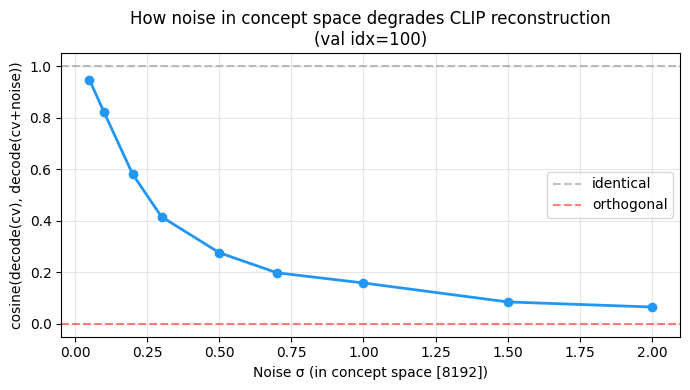

Saved: decode_noise_similarity_sweep.png

Interpretation:
  sim ≈ 1.0  → noisy decode still points at the SAME image region
  sim ≈ 0.0  → noisy decode points at a completely DIFFERENT region


In [18]:
#  Visual summary: cosine similarity vs sigma 
# Shows how quickly the noisy decode diverges from the clean one as σ grows

SIGMAS_SWEEP = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
N_SAMPLES    = 20    # average over N random noise draws per sigma
SWEEP_IDX    = 100   # which val image to use

cv_ref = all_concept_vectors[SWEEP_IDX].numpy()
clean_clip_ref = decode_cv_to_clip(cv_ref)
c_ref = F.normalize(torch.tensor(clean_clip_ref), dim=0)

mean_sims = []
for sigma in SIGMAS_SWEEP:
    sims = []
    for _ in range(N_SAMPLES):
        noisy = cv_ref + np.random.normal(0, sigma, size=cv_ref.shape)
        noisy_clip = decode_cv_to_clip(noisy)
        n_ref = F.normalize(torch.tensor(noisy_clip), dim=0)
        sims.append(F.cosine_similarity(c_ref.unsqueeze(0), n_ref.unsqueeze(0)).item())
    mean_sims.append(np.mean(sims))
    print(f"  σ={sigma:.2f}  mean cosine(clean, noisy) = {np.mean(sims):.4f}")

plt.figure(figsize=(7, 4))
plt.plot(SIGMAS_SWEEP, mean_sims, 'o-', linewidth=2, color='#2196F3')
plt.axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='identical')
plt.axhline(0.0, color='red',  linestyle='--', alpha=0.5, label='orthogonal')
plt.xlabel('Noise σ (in concept space [8192])')
plt.ylabel('cosine(decode(cv), decode(cv+noise))')
plt.title(f'How noise in concept space degrades CLIP reconstruction\n(val idx={SWEEP_IDX})')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("decode_noise_similarity_sweep.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: decode_noise_similarity_sweep.png")
print()
print("Interpretation:")
print("  sim ≈ 1.0  → noisy decode still points at the SAME image region")
print("  sim ≈ 0.0  → noisy decode points at a completely DIFFERENT region")

## Visual proof: original image vs nearest neighbour of noisy decode

Three images side by side:
- **Left**: original val image
- **Middle**: nearest neighbour of `decode(clean_cv)` — should look similar
- **Right**: nearest neighbour of `decode(noisy_cv)` — should look **different**

In [19]:
from torch.utils.data import DataLoader

TRUE_CLIP_PATH = os.path.join("..", "smoothing_data", "true_clip_embeddings_imagenet_val.pt")

if os.path.exists(TRUE_CLIP_PATH):
    print("Loading cached true CLIP embeddings...")
    true_clip_embeddings = torch.load(TRUE_CLIP_PATH, map_location='cpu')
else:
    print("Computing true CLIP embeddings for all 50k val images...")
    # feature_extractor.get_pooled_feats() → [B, 512, H, W]
    # global average pool → [B, 512]  ← one CLIP embedding per image
    loader = DataLoader(probe_val_dataset, batch_size=128, shuffle=False,
                        num_workers=4, pin_memory=True)
    all_true_clip = []
    with torch.no_grad():
        for batch_idx, (imgs, _) in enumerate(loader):
            feats = feature_extractor.get_pooled_feats(imgs.to(args.device))  # [B, 512, H, W]
            emb   = feats.mean(dim=[2, 3])                                     # [B, 512]
            all_true_clip.append(emb.cpu())
            if (batch_idx + 1) % 50 == 0:
                print(f"  {(batch_idx+1)*128}/{len(probe_val_dataset)}")
    true_clip_embeddings = torch.cat(all_true_clip, dim=0)   # [50000, 512]
    torch.save(true_clip_embeddings, TRUE_CLIP_PATH)
    print(f"Saved to {TRUE_CLIP_PATH}")

print(f"True CLIP embeddings: {true_clip_embeddings.shape}")

# L2-normalise for cosine search
true_clip_norm = F.normalize(true_clip_embeddings.to(args.device), dim=-1)  # [50000, 512]
print("Ready.")

Computing true CLIP embeddings for all 50k val images...
  6400/50000
  12800/50000
  19200/50000
  25600/50000
  32000/50000
  38400/50000
  44800/50000
Saved to ../smoothing_data/true_clip_embeddings_imagenet_val.pt
True CLIP embeddings: torch.Size([50000, 512])
Ready.


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image as PILImage
import numpy as np
import torch
import torch.nn.functional as F

SIGMA       = 0.6
TARGET_IDCS = [199, 51, 42, 49498, 4144, 10822]

for target_idx in TARGET_IDCS:
    cv_orig  = all_concept_vectors[target_idx].numpy()
    label_id = all_labels[target_idx].item()

    clean_clip = decode_cv_to_clip(cv_orig)
    noisy_cv   = cv_orig + np.random.normal(0, SIGMA, size=cv_orig.shape)
    noisy_clip = decode_cv_to_clip(noisy_cv)

    sim_clean_noisy = F.cosine_similarity(
        F.normalize(torch.tensor(clean_clip), dim=0).unsqueeze(0),
        F.normalize(torch.tensor(noisy_clip), dim=0).unsqueeze(0)
    ).item()

    nn_clean_sae_idx,  sim_clean_sae  = find_nearest_neighbour(clean_clip, all_clip_norm)
    nn_noisy_sae_idx,  sim_noisy_sae  = find_nearest_neighbour(noisy_clip, all_clip_norm)
    nn_clean_true_idx, sim_clean_true = find_nearest_neighbour(clean_clip, true_clip_norm)
    nn_noisy_true_idx, sim_noisy_true = find_nearest_neighbour(noisy_clip, true_clip_norm)

    def load_img(dataset, idx):
        if hasattr(dataset, 'samples'):
            return PILImage.open(dataset.samples[idx][0]).convert("RGB")
        return None

    panels = [
        (load_img(probe_val_dataset, target_idx),
         f"ORIGINAL\n{get_class_name(PROBE_DATASET, label_id)}"),
        (load_img(probe_val_dataset, nn_clean_sae_idx),
         f"NN(clean) SAE gallery\n{get_class_name(PROBE_DATASET, all_labels[nn_clean_sae_idx].item())}\nsim={sim_clean_sae:.3f}"),
        (load_img(probe_val_dataset, nn_noisy_sae_idx),
         f"NN(noisy) SAE gallery\n{get_class_name(PROBE_DATASET, all_labels[nn_noisy_sae_idx].item())}\nsim={sim_noisy_sae:.3f}"),
        (load_img(probe_val_dataset, nn_clean_true_idx),
         f"NN(clean) TRUE CLIP gallery\n{get_class_name(PROBE_DATASET, all_labels[nn_clean_true_idx].item())}\nsim={sim_clean_true:.3f}"),
        (load_img(probe_val_dataset, nn_noisy_true_idx),
         f"NN(noisy) TRUE CLIP gallery\n{get_class_name(PROBE_DATASET, all_labels[nn_noisy_true_idx].item())}\nsim={sim_noisy_true:.3f}"),
    ]

    fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
    for ax, (img, title) in zip(axes, panels):
        if img is not None:
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, "not found", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontsize=8)
        ax.axis("off")

    fig.suptitle(
        f"idx={target_idx}  σ={SIGMA}  |  cosine(clean_clip, noisy_clip) = {sim_clean_noisy:.3f}",
        fontsize=10, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(f"decode_nn_5panel_idx{target_idx}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: decode_nn_5panel_idx{target_idx}.png")

## Jonas: Direct Retrieval in SAE Space [8192] — No Decoder

**Key insight:** Do NOT decode back to 512 before retrieval — decoder is in-distribution trained, noisy vectors may be OOD.

**Why cv_orig is NOT retrieved:**  
`cv_orig` is already in the gallery → top-1 always returns itself with sim=1.0 (trivial).  
The original image is shown in row 0 as a fixed reference only.

**Pipeline:**
```
cv_iso   [8192]  →  cosine search in SAE gallery [50000, 8192]  →  top-5 images
cv_mani  [8192]  →  cosine search in SAE gallery [50000, 8192]  →  top-5 different images
```

**4 figures per target (iso/mani × top/least):**
```
Row 0:   original image  |  original cv bars  |  noisy cv bars   ← fixed reference
Row 1:   matched img #1  |  matched TRUE bars  |  noisy cv bars
Row 2:   matched img #2  |  matched TRUE bars  |  noisy cv bars
Row 3:   matched img #3  |  matched TRUE bars  |  noisy cv bars
Row 4:   matched img #4  |  matched TRUE bars  |  noisy cv bars
Row 5:   matched img #5  |  matched TRUE bars  |  noisy cv bars
```
Middle = what the matched image actually has. Right = our noisy query (repeated each row for comparison).

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.decomposition import PCA
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

SIGMA_ISO   = 0.5
SIGMA_MANI  = 0.5
K_NEIGH     = 500
TOP_K_SHOW  = 10
TOP_N_IMGS  = 5
TARGET_IDCS = [199, 51, 42]

C_ORIG       = '#636363'
C_ISO        = '#4a1486'
C_MANI       = '#9e3d8f'
C_ISO_LEAST  = '#6baed6'
C_MANI_LEAST = '#9e9ac8'

sae_gallery_raw = all_concept_vectors.to(args.device)
print(f"SAE gallery (raw Euclidean): {sae_gallery_raw.shape}")


def top_n_in_sae(cv_np, n=5):
    with torch.no_grad():
        q     = torch.tensor(cv_np, dtype=torch.float32, device=args.device)
        diffs = sae_gallery_raw - q.unsqueeze(0)
        dists = diffs.norm(dim=1)
        top   = dists.topk(n, largest=False)
    return top.indices.cpu().tolist(), (-top.values).cpu().tolist()


def load_img(dataset, idx):
    try:
        if hasattr(dataset, 'samples'):
            return PILImage.open(dataset.samples[idx][0]).convert("RGB")
    except Exception:
        pass
    return None


def effect_bars(ax, cv_orig_v, cv_noisy_v, c_noisy, title, mode='top'):
    """
    Effect of smoothing on original concepts.
    - Ordering by ORIGINAL vector (top-k desc or least-k active asc)
    - Green bar  = original activation
    - Colored bar = noisy activation for SAME concept
    - Concept name INSIDE green bar (white text)
    - Numbers at end of each bar (no overlap with names)
    """
    orig  = np.array(cv_orig_v)
    noisy = np.array(cv_noisy_v)

    if mode == 'top':
        idxs  = np.argsort(-orig)[:TOP_K_SHOW]
        order = np.argsort(orig[idxs])[::-1]
    else:
        active = np.where(orig > 1e-6)[0]
        if len(active) == 0:
            ax.text(0.5, 0.5, 'no active concepts', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8)
            ax.set_title(title, fontsize=6.5, pad=2)
            ax.axis('off')
            return
        idxs  = active[np.argsort(orig[active])[:TOP_K_SHOW]]
        order = np.argsort(orig[idxs])

    orig_vals  = orig[idxs][order]
    noisy_vals = noisy[idxs][order]
    names = [(concept_names[i] if concept_names else f"c{i}")[:20]
             for i in idxs[order]]

    y, h = np.arange(len(idxs)), 0.35
    ax.barh(y - h/2, orig_vals,  height=h, color='#1b7837', alpha=0.85, label='Original')
    ax.barh(y + h/2, noisy_vals, height=h, color=c_noisy,   alpha=0.85, label='Noisy')
    ax.invert_yaxis()
    ax.set_yticks([])   # no external labels — names go inside bars

    vmax = max(float(orig_vals.max()), float(noisy_vals.max()), 0.001)
    xmax = vmax * 1.35
    ax.set_xlim(0, xmax)

    for yi, (name, ov, nv) in enumerate(zip(names, orig_vals, noisy_vals)):
        # concept name inside green bar — white
        ax.text(vmax * 0.015, yi - h/2,
                name, va='center', ha='left', fontsize=6.5,
                color='white', clip_on=True)
        # original value at end of green bar
        txt_o = f"{ov:.2f}" if ov >= 0.01 else f"{ov:.2e}"
        ax.text(ov + vmax * 0.02, yi - h/2,
                txt_o, va='center', ha='left', fontsize=6,
                color='#222', clip_on=True)
        # noisy value at end of noisy bar
        txt_n = f"{nv:.2f}" if nv >= 0.01 else f"{nv:.2e}"
        ax.text(nv + vmax * 0.02, yi + h/2,
                txt_n, va='center', ha='left', fontsize=6,
                color='#222', clip_on=True)

    ax.set_xticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_title(title, fontsize=6.5, pad=2)
    ax.legend(fontsize=6, loc='lower right', frameon=False)

print("Helpers ready.")

In [ ]:
for target_idx in TARGET_IDCS:
    cv_orig    = all_concept_vectors[target_idx].numpy()
    label_id   = all_labels[target_idx].item()
    true_class = get_class_name(PROBE_DATASET, label_id)

    cv_iso = cv_orig + np.random.normal(0, SIGMA_ISO, size=cv_orig.shape)
    nn_idcs = knn_index.get_nns_by_item(target_idx, K_NEIGH)
    X_nb    = np.stack([knn_index.get_item_vector(i) for i in nn_idcs])
    mean_nn = X_nb.mean(axis=0)
    pca     = PCA(n_components=K_NEIGH)
    pca.fit(X_nb - mean_nn)
    ev, Vt  = pca.explained_variance_, pca.components_
    alpha   = SIGMA_MANI / float(np.sqrt(max(ev[0], 1e-12)))
    cv_w    = (cv_orig - mean_nn) @ Vt.T / np.sqrt(ev)
    cv_mani = (cv_w + np.random.normal(0, alpha, size=len(ev))) @ (np.sqrt(ev)[:, None] * Vt) + mean_nn

    dist_iso  = float(np.linalg.norm(cv_iso  - cv_orig))
    dist_mani = float(np.linalg.norm(cv_mani - cv_orig))
    iso_idxs,  _ = top_n_in_sae(cv_iso,  n=TOP_N_IMGS)
    mani_idxs, _ = top_n_in_sae(cv_mani, n=TOP_N_IMGS)

    for mode in ['top', 'least']:
        mode_lbl = 'Top' if mode == 'top' else 'Least'
        c_iso_m  = C_ISO        if mode == 'top' else C_ISO_LEAST
        c_mani_m = C_MANI       if mode == 'top' else C_MANI_LEAST

        for noisy_cv, noisy_idxs, label, c_noisy, dist in [
            (cv_iso,  iso_idxs,  'Iso',      c_iso_m,  dist_iso),
            (cv_mani, mani_idxs, 'Manifold', c_mani_m, dist_mani),
        ]:
            sigma_val = SIGMA_ISO if label == 'Iso' else SIGMA_MANI
            suptitle  = (
                f"{label} smoothing  {mode_lbl} {TOP_K_SHOW} concepts\n"
                f"true: {true_class}  sigma={sigma_val}\n"
                f"L2 distance from original = {dist:.2f}"
            )
            base = f"sae_retrieval_{label.lower()}_{mode}_idx{target_idx}"

            # ── Original figure: image + effect bars ──────────────────────────
            fig0, axes0 = plt.subplots(2, 1, figsize=(5, 6.0),
                                       gridspec_kw={'height_ratios': [0.8, 3],
                                                    'hspace': 0.4})
            img0 = load_img(probe_val_dataset, target_idx)
            if img0: axes0[0].imshow(img0)
            axes0[0].axis('off')
            axes0[0].set_title(f"ORIGINAL  {true_class[:30]}", fontsize=7)

            effect_bars(axes0[1], cv_orig, noisy_cv, c_noisy,
                        f"Effect of {label} smoothing on original {mode_lbl} {TOP_K_SHOW} concepts",
                        mode)

            fig0.suptitle(suptitle, fontsize=7, y=0.99)
            fig0.savefig(f"{base}_original.png", dpi=150, bbox_inches='tight')
            plt.show(); plt.close(fig0)

            # ── One match per figure: image + effect bars ─────────────────────
            for mi, ni in enumerate(noisy_idxs):
                cv_ni  = all_concept_vectors[ni].numpy()
                lbl_ni = get_class_name(PROBE_DATASET, all_labels[ni].item())

                fig_m = plt.figure(figsize=(8, 5.0))
                gs_m  = gridspec.GridSpec(1, 2, figure=fig_m,
                                          width_ratios=[1, 2.5],
                                          wspace=0.3,
                                          top=0.72, bottom=0.04)

                ax_img_m = fig_m.add_subplot(gs_m[0])
                img_m = load_img(probe_val_dataset, ni)
                if img_m: ax_img_m.imshow(img_m)
                ax_img_m.axis('off')
                ax_img_m.set_title(f"Match #{mi+1}\n{lbl_ni[:22]}", fontsize=7)

                # green=matched image's concepts, colored=noisy query for same concepts
                effect_bars(fig_m.add_subplot(gs_m[1]), cv_ni, noisy_cv, c_noisy,
                            f"Matched #{mi+1}: effect of {label} noise  ({mode_lbl})",
                            mode)

                fig_m.suptitle(suptitle, fontsize=7, y=0.97)
                fig_m.savefig(f"{base}_match{mi+1}.png", dpi=150, bbox_inches='tight')
                plt.close(fig_m)

        print(f"Saved {base}  (L2_iso={dist_iso:.2f}  L2_mani={dist_mani:.2f})")